# 4강. 3자 종합 비교 — 가위바위보로 보는 OpenCV vs YOLO vs MediaPipe

(원래 워크샵 Part 1 자료로 만들어졌으며, 1~3강에서 배운 세 기술을 같은 과제로 직접 비교합니다.)

같은 문제(가위바위보 손모양 판정)를 세 가지 완전히 다른 방식으로 풀어보고,
**검출 → 전처리 → 인식/분류 → 후처리** 파이프라인 사고로 왜 결과가 갈리는지 확인합니다.

이 노트북은 새 알고리즘을 만들지 않습니다. 이 워크샵의 세 프로젝트
(`opencv2_rps_classic`, `yolo1_rps`, `mediapipe1_hand_lite`)가 이미 검증해 둔
코드를 그대로 불러와 **같은 6장의 실사진**에 돌려보고 나란히 비교합니다.
웹캠은 열지 않습니다 — 전부 정지 이미지입니다.

## 학습 목표
1. 비전 문제를 검출→전처리→인식/분류→후처리 4단계로 쪼개 볼 수 있다
2. 같은 문제에서 세 기술의 정확도·모델 크기·실패 양상이 어떻게 다른지 실측으로 안다
3. "왜 이 기술이 여기서 실패하는가"를 설명할 수 있다(추측이 아니라 근거로)


In [1]:
import sys
from pathlib import Path


def find_workshop_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "src" / "yolo" / "rps").is_dir():
            return candidate
    raise FileNotFoundError("워크샵 루트를 찾지 못했습니다")


WORKSHOP = find_workshop_root(Path.cwd())
FIXTURES = WORKSHOP / "src" / "yolo" / "rps" / "tests" / "fixtures"

# 이 픽스처는 원래 yolo1_rps 프로젝트의 테스트용 실사진이다.
# mediapipe1_hand_lite도 같은 픽스처로 회귀 테스트를 돈다 — 세 기술을
# "같은 시험지"로 비교하기 위해 이 노트북도 그대로 재사용한다.
CASES = [
    ("rock_0.png", "ROCK"), ("rock_1.png", "ROCK"),
    ("paper_0.png", "PAPER"), ("paper_1.png", "PAPER"),
    ("scissors_0.png", "SCISSORS"), ("scissors_1.png", "SCISSORS"),
]

for filename, expected in CASES:
    assert (FIXTURES / filename).exists(), f"픽스처 없음: {filename}"

print(f"픽스처 경로: {FIXTURES}")
print(f"이미지 {len(CASES)}장 확인 완료 (rock 2 / paper 2 / scissors 2)")


픽스처 경로: /Users/sanguinekim/Documents/3_Code/Vibe/Project/260728_vision_vibe_workshop/src/yolo/rps/tests/fixtures
이미지 6장 확인 완료 (rock 2 / paper 2 / scissors 2)


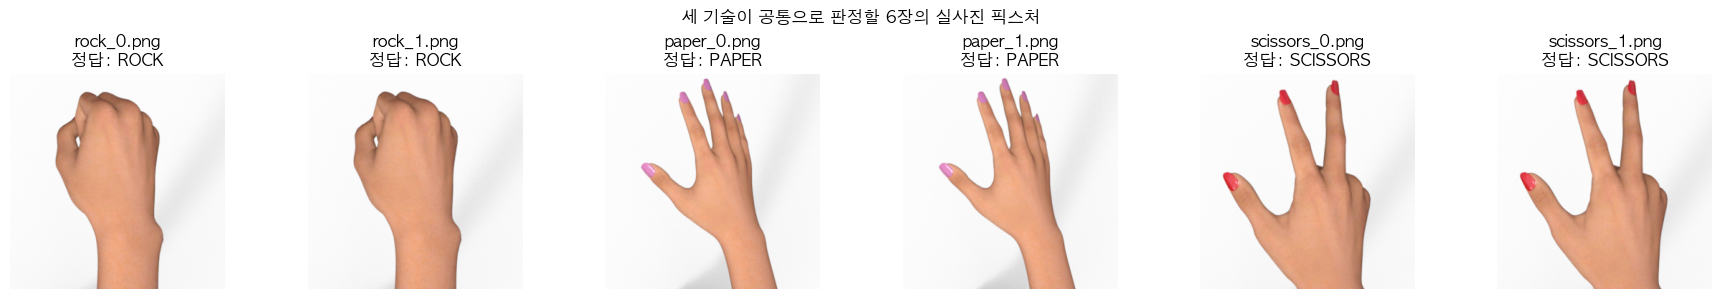

In [2]:
import cv2
import matplotlib.pyplot as plt
from matplotlib import font_manager

# 그래프 안의 한글이 깨지지 않도록(□□□) OS별로 있는 한글 폰트를 하나 고른다.
_installed = {f.name for f in font_manager.fontManager.ttflist}
for _font in ("AppleGothic", "Malgun Gothic", "NanumGothic"):
    if _font in _installed:
        plt.rcParams["font.family"] = _font
        break
plt.rcParams["axes.unicode_minus"] = False

fig, axes = plt.subplots(1, 6, figsize=(18, 3))
for ax, (filename, expected) in zip(axes, CASES):
    frame = cv2.imread(str(FIXTURES / filename))
    ax.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    ax.set_title(f"{filename}\n정답: {expected}")
    ax.axis("off")
plt.suptitle("세 기술이 공통으로 판정할 6장의 실사진 픽스처")
plt.tight_layout()
plt.show()


## 1. OpenCV 전통기법 — 규칙을 사람이 짠다

`opencv2_rps_classic/rps_classic/pipeline.py`의 `detect()`를 그대로 가져와 쓴다.
YCrCb 피부색 검출 → 최대 컨투어 → Convexity Defects(볼록 껍질 결함)로 손가락 개수를
세는 규칙 기반 파이프라인 — 학습된 모델이 없다(용량 0바이트).


In [3]:
sys.path.insert(0, str(WORKSHOP / "src" / "opencv" / "rps_classic"))
from rps_classic.pipeline import detect as opencv_detect
import cv2

print("=== OpenCV 전통기법 (opencv2_rps_classic) ===")
opencv_correct = 0
for filename, expected in CASES:
    frame = cv2.imread(str(FIXTURES / filename))
    result = opencv_detect(frame)
    got = result.gesture.name
    ok = got == expected
    opencv_correct += ok
    print(f"{filename:16s} 정답={expected:9s} 예측={got:9s} {'O' if ok else 'X'}")
print(f"\nOpenCV 정확도: {opencv_correct}/6")


=== OpenCV 전통기법 (opencv2_rps_classic) ===
rock_0.png       정답=ROCK      예측=ROCK      O
rock_1.png       정답=ROCK      예측=ROCK      O
paper_0.png      정답=PAPER     예측=UNKNOWN   X
paper_1.png      정답=PAPER     예측=UNKNOWN   X
scissors_0.png   정답=SCISSORS  예측=UNKNOWN   X
scissors_1.png   정답=SCISSORS  예측=UNKNOWN   X

OpenCV 정확도: 2/6


**왜 4장이 UNKNOWN인가?** `opencv2_rps_classic/README.md`의 224조합(마스크4×깊이8×각도7)
전수탐색 결과: 보(paper)의 실패는 마스크/임계값을 더 다듬으면 완화될 여지가 있지만,
가위(scissors)의 실패는 **표현 방식 자체의 한계**다 — 볼록 껍질 결함(convexity defect)은
"손가락 사이 골이 몇 개인가"만 셀 뿐 "그 골이 엄지 쪽인가"는 알 수 없다.
가위(검지+중지 편 상태)와 엄지를 편 다른 포즈가 기하학적으로 구분되지 않는다.

## 2. MediaPipe — 구글이 이미 학습해 둔 범용 모델

`mediapipe1_hand_lite/hand_lite/`의 `HandLite`(HandLandmarker 래퍼)와 `classify()`를
그대로 가져와 쓴다. 21개 손 랜드마크 각각에 **이름**(엄지=4번 등)이 붙어 있어
"어느 손가락이 얼마나 굽었나"를 직접 판정할 수 있다.


In [4]:
sys.path.insert(0, str(WORKSHOP / "src" / "mediapipe" / "hand_lite"))
from hand_lite.gesture import classify
from hand_lite.landmarker import HandLite

print("=== MediaPipe HandLandmarker (mediapipe1_hand_lite) ===")
mp_correct = 0
for filename, expected in CASES:
    frame = cv2.imread(str(FIXTURES / filename))
    with HandLite(num_hands=1) as engine:
        hands = engine.detect(frame, timestamp_ms=0)
    got = classify(hands[0]).name if len(hands) == 1 else "NO_HAND"
    ok = got == expected
    mp_correct += ok
    print(f"{filename:16s} 정답={expected:9s} 예측={got:9s} {'O' if ok else 'X'}")
print(f"\nMediaPipe 정확도: {mp_correct}/6")


=== MediaPipe HandLandmarker (mediapipe1_hand_lite) ===


I0000 00:00:1785468270.134600 1753560 gl_context.cc:407] GL version: 2.1 (2.1 Metal - 89.4), renderer: Apple M3 Pro
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1785468270.152614 1753562 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1785468270.174446 1753562 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1785468270.212098 1753567 landmark_projection_calculator.cc:81] Using NORM_RECT without IMAGE_DIMENSIONS is only supported for the square ROI. Provide IMAGE_DIMENSIONS or use PROJECTION_MATRIX.
I0000 00:00:1785468270.224055 1753577 gl_context.cc:407] GL version: 2.1 (2.1 Metal - 89.4), renderer: Apple M3 Pro
W0000 00:00:1785468270.228244 1753579 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. 

rock_0.png       정답=ROCK      예측=ROCK      O
rock_1.png       정답=ROCK      예측=ROCK      O
paper_0.png      정답=PAPER     예측=PAPER     O
paper_1.png      정답=PAPER     예측=PAPER     O
scissors_0.png   정답=SCISSORS  예측=SCISSORS  O


scissors_1.png   정답=SCISSORS  예측=SCISSORS  O

MediaPipe 정확도: 6/6


I0000 00:00:1785468270.374292 1753647 gl_context.cc:407] GL version: 2.1 (2.1 Metal - 89.4), renderer: Apple M3 Pro
W0000 00:00:1785468270.377997 1753650 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1785468270.381685 1753650 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
I0000 00:00:1785468270.417968 1753665 gl_context.cc:407] GL version: 2.1 (2.1 Metal - 89.4), renderer: Apple M3 Pro
W0000 00:00:1785468270.420832 1753668 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1785468270.424196 1753668 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


엄지를 **이름으로 지목**할 수 있다는 것이 OpenCV와의 결정적 차이다. 랜드마크 4번이
곧 엄지끝이므로 "엄지가 벌어졌는가"를 직접 계산할 수 있다 — OpenCV의 볼록 껍질은
이 정보 자체가 없다.

## 3. YOLO — 내 도메인 대상을 직접 학습시킨 탐지기

`yolo1_rps/rps/detector.py`의 `RPSDetector`를 그대로 가져와 쓴다. 단, 이 프로젝트는
`ultralytics`/`torch`처럼 무거운 별도 의존성을 쓰기 때문에 **별도 가상환경**
(`yolo1_rps/venv`)에 격리되어 있다 — 이 노트북의 커널(루트 venv)에는 없다.
그래서 서브프로세스로 그 venv의 파이썬을 직접 호출해 결과를 받는다
(`part1_comparison/scripts/yolo_infer_fixtures.py`).


In [5]:
import json
import subprocess

MODEL = WORKSHOP / "src" / "yolo" / "rps" / "models" / "rps_yolo11x_leeyunjai.pt"  # yolo1_rps 자체 테스트가 쓰는 모델
SCRIPT = WORKSHOP / "lecture" / "scripts" / "yolo_infer_fixtures.py"
YOLO_PY = WORKSHOP / "src" / "yolo" / "rps" / "venv" / "bin" / "python"

result = subprocess.run(
    [str(YOLO_PY), str(SCRIPT), str(FIXTURES), str(MODEL)],
    capture_output=True, text=True, check=True,
)
detections = json.loads(result.stdout.strip().splitlines()[-1])

print("=== YOLO (yolo1_rps, rps_yolo11x_leeyunjai.pt, conf=0.25) — 별도 venv 서브프로세스 실행 ===")
yolo_correct = 0
for filename, expected in CASES:
    det = detections.get(filename)
    got = det["move"].upper() if det else "NO_DETECTION"
    conf = f"{det['confidence']:.2f}" if det else "-"
    ok = got == expected
    yolo_correct += ok
    print(f"{filename:16s} 정답={expected:9s} 예측={got:9s} conf={conf} {'O' if ok else 'X'}")
print(f"\nYOLO 정확도: {yolo_correct}/6  ← 실측 결과, [인용]이 아니라 [사실]")


=== YOLO (yolo1_rps, rps_yolo11x_leeyunjai.pt, conf=0.25) — 별도 venv 서브프로세스 실행 ===
rock_0.png       정답=ROCK      예측=ROCK      conf=0.64 O
rock_1.png       정답=ROCK      예측=ROCK      conf=0.64 O
paper_0.png      정답=PAPER     예측=PAPER     conf=0.73 O
paper_1.png      정답=PAPER     예측=PAPER     conf=0.72 O
scissors_0.png   정답=SCISSORS  예측=PAPER     conf=0.87 X
scissors_1.png   정답=SCISSORS  예측=PAPER     conf=0.88 X

YOLO 정확도: 4/6  ← 실측 결과, [인용]이 아니라 [사실]


**중요한 발견**: YOLO가 가위 2장을 전부 "보(paper)"로, 그것도 0.87~0.88의
**높은 확신도**로 오분류했다. confidence가 높다고 정답이라는 보장이 없다 —
이 모델이 학습 데이터에서 가위 포즈를 충분히 못 봤거나, 이 정지 이미지의 손 각도가
학습 분포 밖에 있을 가능성이 크다. "학습된 모델이니 믿을 만하다"가 아니라
**학습 데이터가 내 사용 조건을 덮는지**가 핵심 질문이라는 걸 보여주는 실측 사례다.

## 4. 3자 비교 — 실측 요약


In [6]:
import os

MODEL_SIZES = {
    "OpenCV 전통기법": 0,
    "MediaPipe HandLandmarker": os.path.getsize(WORKSHOP / "src" / "mediapipe" / "hand_lite" / "models" / "hand_landmarker.task"),
    "YOLO11x (오늘 실측)": os.path.getsize(MODEL),
    "YOLO11n (참고 — 경량 버전)": os.path.getsize(WORKSHOP / "src" / "yolo" / "rps" / "models" / "rps_yolo11n_gholamreza.pt"),
}
ACCURACY = {
    "OpenCV 전통기법": f"{opencv_correct}/6",
    "MediaPipe HandLandmarker": f"{mp_correct}/6",
    "YOLO11x (오늘 실측)": f"{yolo_correct}/6",
    "YOLO11n (참고 — 경량 버전)": "이 노트북에서 미측정",
}

print(f"{'접근':28s} {'모델 용량':>12s}   {'6장 정확도':>10s}   근거")
print("-" * 78)
for name, size in MODEL_SIZES.items():
    mb = size / 1_000_000
    acc = ACCURACY[name]
    tag = "[사실] 이 노트북 실측" if "미측정" not in acc else "[사실] 파일 크기만"
    print(f"{name:28s} {mb:9.2f} MB   {acc:>10s}   {tag}")


접근                                  모델 용량       6장 정확도   근거
------------------------------------------------------------------------------
OpenCV 전통기법                       0.00 MB          2/6   [사실] 이 노트북 실측
MediaPipe HandLandmarker          7.82 MB          6/6   [사실] 이 노트북 실측
YOLO11x (오늘 실측)                 114.42 MB          4/6   [사실] 이 노트북 실측
YOLO11n (참고 — 경량 버전)              5.47 MB   이 노트북에서 미측정   [사실] 파일 크기만


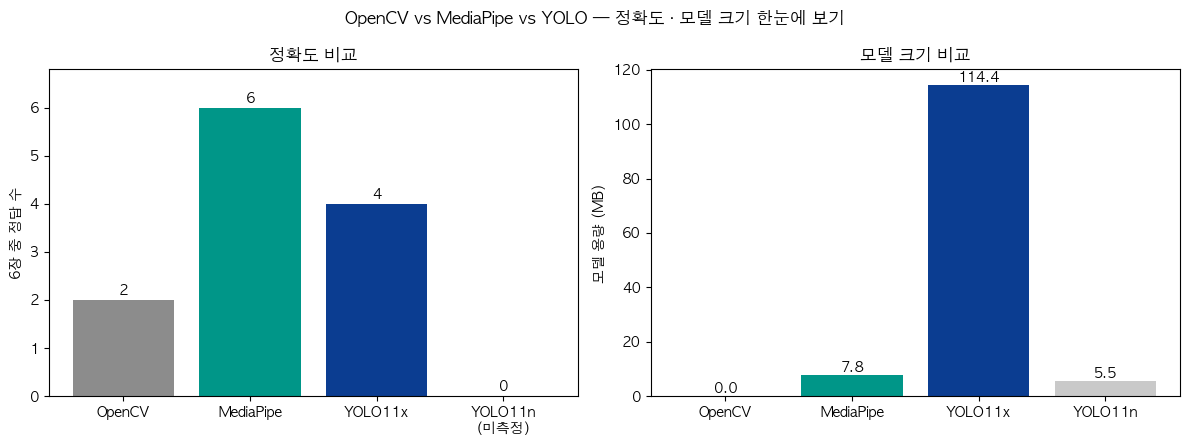

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

names = list(ACCURACY.keys())
acc_values = [int(ACCURACY[n].split("/")[0]) if "/" in ACCURACY[n] else 0 for n in names]
colors = ["#8c8c8c", "#009688", "#0b3d91", "#c9c9c9"]

ax1.bar(range(len(names)), acc_values, color=colors)
ax1.set_xticks(range(len(names)))
ax1.set_xticklabels(["OpenCV", "MediaPipe", "YOLO11x", "YOLO11n\n(미측정)"], rotation=0)
ax1.set_ylim(0, 6.8)  # 막대 위 숫자가 제목과 겹치지 않도록 여유
ax1.set_ylabel("6장 중 정답 수")
ax1.set_title("정확도 비교")
for i, v in enumerate(acc_values):
    ax1.text(i, v + 0.1, str(v), ha="center")

size_values = [MODEL_SIZES[n] / 1_000_000 for n in names]
ax2.bar(range(len(names)), size_values, color=colors)
ax2.set_xticks(range(len(names)))
ax2.set_xticklabels(["OpenCV", "MediaPipe", "YOLO11x", "YOLO11n"], rotation=0)
ax2.set_ylabel("모델 용량 (MB)")
ax2.set_title("모델 크기 비교")
for i, v in enumerate(size_values):
    ax2.text(i, v + 1, f"{v:.1f}", ha="center")

plt.suptitle("OpenCV vs MediaPipe vs YOLO — 정확도 · 모델 크기 한눈에 보기")
plt.tight_layout()
plt.show()


> **spec.md·Part1 강의자료 갱신 필요**: 두 문서 모두 "YOLO 6/6[인용]"으로 적혀 있는데
> 이 노트북의 실측은 **YOLO11x 4/6**이다. 오분류 2건 모두 가위→보, 높은 확신도(0.87~0.88).
> 문서의 [인용] 표시를 이 노트북 결과로 교체하는 것을 권장한다.

## 5. 파이프라인 사고로 정리하기

| 단계 | OpenCV | YOLO | MediaPipe |
|---|---|---|---|
| ① 검출 | 피부색 마스크로 손 영역 찾기 | 학습된 신경망이 손 전체(bounding box) 찾기 | 팜 디텍터가 손 전체 찾기 |
| ② 전처리 | 최대 컨투어 추출 | 모델 입력 크기로 리사이즈 | 크롭 후 랜드마크 회귀 입력 |
| ③ 인식/분류 | 볼록 껍질 결함 개수 → 규칙 | 클래스 확률(rock/paper/scissors) | 21개 랜드마크 좌표 → 규칙 |
| ④ 후처리 | UNKNOWN 기권 판정 | confidence threshold | handedness 보정 |

세 기술 모두 **같은 4단계**를 거치지만, ①③ 단계를 "사람이 규칙으로" 할지
"데이터로 학습"할지 "구글이 이미 학습해 둔 것을 쓸지"가 갈린다 — 이게 오늘의 지도다.

## 6. 미니 워크시트 — 내 도메인에 적용한다면

Part 5(16:00~16:40)에서 다룰 내용을 미리 적어보세요.

1. 내가 풀고 싶은 비전 문제는 무엇인가요?
2. 그 문제를 검출→전처리→인식/분류→후처리 4단계로 쪼개면 각 단계는 무엇인가요?
3. 대상이 손·얼굴·사람처럼 범용적인가요, 아니면 내 도메인에 특화된 대상(제품, 문서 양식 등)인가요?
4. 위 답을 바탕으로 OpenCV/YOLO/MediaPipe 중 어느 것으로 1차 프로토타입을 만들어볼 건가요? 왜인가요?
